Assignment 5

### Epilepsy
Datasource: https://data.mendeley.com/datasets/5pc2j46cbc/1

In [1]:
!wget -O eeg.edf https://data.mendeley.com/public-files/datasets/5pc2j46cbc/files/6a2d23f5-9129-4970-9d1c-05f6012f9cd2/file_downloaded

--2024-10-30 22:33:43--  https://data.mendeley.com/public-files/datasets/5pc2j46cbc/files/6a2d23f5-9129-4970-9d1c-05f6012f9cd2/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/85ebf7ae-ff76-4f17-bab7-e47e968b0fd4 [following]
--2024-10-30 22:33:44--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/85ebf7ae-ff76-4f17-bab7-e47e968b0fd4
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 52.92.2.202, 3.5.65.111, 52.92.17.138, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|52.92.2.202|:443... 

In [3]:
# download train test splwgits
!wget --quiet -O x_test.npy https://data.mendeley.com/public-files/datasets/5pc2j46cbc/files/93b81166-0e48-4dc0-ac20-b7167f7606c5/file_downloaded
!wget --quiet -O x_train.npy https://data.mendeley.com/public-files/datasets/5pc2j46cbc/files/169dca1c-4992-43d3-9c94-030de59c2524/file_downloaded
!wget --quiet -O y_test.npy https://data.mendeley.com/public-files/datasets/5pc2j46cbc/files/adf1c2fd-81ef-4f87-86cc-56d75bba8c31/file_downloaded
!wget --quiet -O y_train.npy https://data.mendeley.com/public-files/datasets/5pc2j46cbc/files/62accb90-a1b2-4b50-bde5-fbe6096f165f/file_downloaded

In [2]:
!pip install mne --quiet
!pip install fathon --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 9.0 MB/s eta 0:00:00


In [4]:
import mne

# Load the EDF file
edf_file = 'eeg.edf'
raw = mne.io.read_raw_edf(edf_file, preload=True)

# Access data and info
info = raw.info

print(info)

Extracting EDF parameters from /content/eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 5401499  =      0.000 ... 10802.998 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1-Ref, EEG Fp2-Ref, EEG F3-Ref, EEG F4-Ref, EEG C3-Ref, ...
 chs: 19 EEG
 custom_ref_applied: False
 highpass: 1.0 Hz
 lowpass: 70.0 Hz
 meas_date: 2015-07-09 05:36:39 UTC
 nchan: 19
 projs: []
 sfreq: 500.0 Hz
 subject_info: 3 items (dict)
>


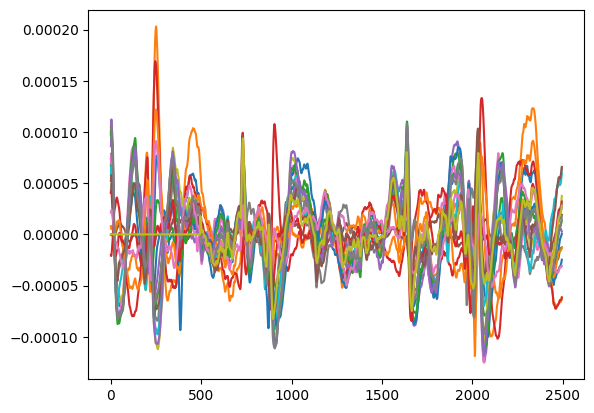

In [5]:
import matplotlib.pyplot as plt
import numpy as np

frequency = int(raw.info['sfreq'])
# crop 5 seconds data. freq.=500
data = raw._data[:,:frequency*5]
channels = data.shape[0]
for i in range(channels):
  plt.plot( data[i][5:])

### Box-Counting

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def box_count(data, box_size):
    """
    Count the number of boxes of a given size that are required to cover the data.

    Parameters:
        data (np.ndarray): The EEG data time series.
        box_size (int): The size of the box to cover the data.

    Returns:
        int: The number of boxes needed to cover the data.
    """
    data_min = np.min(data)
    data_max = np.max(data)
    # Normalize the data to fit within [0, 1]
    normalized_data = (data - data_min) / (data_max - data_min)

    # Create the grid of boxes
    grid = np.zeros((box_size, box_size))

    for i in range(len(normalized_data)):
        x_idx = int(i * box_size / len(data))  # X coordinate (time dimension)
        y_idx = int(normalized_data[i] * (box_size - 1))  # Y coordinate (EEG signal)
        grid[x_idx, y_idx] = 1  # Mark the box as filled

    # Count the number of filled boxes
    return np.sum(grid > 0)

def fractal_dimension(data, box_sizes, plot=False):
    """
    Calculate the fractal dimension of a time series using the box-counting method.

    Parameters:
        data (np.ndarray): The EEG data time series.
        box_sizes (list): A list of box sizes to use for the calculation.

    Returns:
        float: The estimated fractal dimension.
    """
    counts = []

    # Count the number of boxes for each size
    for box_size in box_sizes:
        counts.append(box_count(data, box_size))

    # Perform a log-log plot
    log_box_sizes = np.log(1/np.array(box_sizes))
    log_counts = np.log(np.array(counts) + 1e-10)

    # Linear fit to estimate the slope (fractal dimension)
    slope, intercept = np.polyfit(log_box_sizes, log_counts, 1)

    if plot:
      plt.plot(log_box_sizes,log_counts)
      plt.xlabel("log(box_sizes)")
      plt.ylabel("log_counts")
    # fractal dimension is the opposite of fitting co-efficient
    return -slope


# Choose different box sizes (scales)
box_sizes = np.arange(10, 100, 10)

# fd = fractal_dimension(filtered_signal, box_sizes)
# print(f"Fractal Dimension(slope): {fd}")



### Higuchi Fractal Dimension

In [7]:
import numpy as np
from scipy.stats import linregress

def L_m(X, k, m):
    """Calculate L_m(k) for a given k and m."""
    N = len(X)
    fract_part = (N - m) // k
    terms = [
        abs(X[m + i * k] - X[m + (i - 1) * k])
        for i in range(1,  fract_part)
    ]
    return (N - 1) / (fract_part * k**2) * sum(terms)

def L(X, k):
    """Calculate L(k) as the average of L_m(k) for m = 1, ..., k."""
    L_m_values = [L_m(X, k, m) for m in range(1, k + 1)] # m goes for 1 to k
    return sum(L_m_values) / k

def higuchi_fractal_dimension(X, k_max=10,plot=False):
    """Calculate the Higuchi Fractal Dimension (HFD) for a time series X."""
    log_k = []
    log_Lk = []

    # Calculate log(1/k) and log(L(k)) for each k
    for k in range(1, k_max + 1):
        log_k.append(np.log(1 / k))
        log_Lk.append(np.log(L(X, k)))

    # Perform linear regression to find the slope
    slope, _, _, _, _ = linregress(log_k, log_Lk)
    if plot:
      plt.plot(log_k, log_Lk)
      plt.xlabel("log(k)")
      plt.ylabel("log_Lk")
    # fractal dimension is the opposite of fitting co-efficient
    return slope

# Example usage with a sample time series
# hfd = higuchi_fractal_dimension(filtered_signal, k_max=10)
# print("Higuchi Fractal Dimension (slope):", hfd)


### Multi fractals

In [8]:
import fathon
from fathon import fathonUtils as fu

def multi_fractals(signal):
  mfdfa_data = signal.copy()

  # calculate cumulative sum
  mfdfa_data = fu.toAggregated(mfdfa_data)
  pymfdfa = fathon.MFDFA(mfdfa_data)

  winSizes = fu.linRangeByStep(10, 400) # window sizes. like box-sizes
  qs = np.arange(-3, 4, 2)  # different fluctuation levels (didn't get it)  # normally fractal dimension is calculated at q=2
  n, F = pymfdfa.computeFlucVec(winSizes, qs, revSeg=True, polOrd=1)

  fractals, list_H_intercept = pymfdfa.fitFlucVec()
  # return multi fractals
  return fractals

# fractals = multi_fractals(data[0])
# fractals

### Modeling

In [18]:
x_train = np.load('x_train.npy')
x_test = np.load('x_test.npy')
y_train = np.load('y_train.npy')
y_test = np.load('y_test.npy')
x_train.shape

(7011, 19, 500)

In [11]:
from tqdm import tqdm

def compute_fractal_features(one_signal):
  # box-counting feature
  fd = fractal_dimension(one_signal, box_sizes)
  # hfg
  hfd = higuchi_fractal_dimension(one_signal, k_max=10)
  # multi-fractals
  mfractals = multi_fractals(one_signal)

  return np.concatenate((np.array([fd,hfd]), mfractals))

def transform_eeg_data(eeg_signal):
  # takes eeg signal of shape(n, channel, samples)
  # returns n * features
  transformed_data = []

  for n in tqdm(eeg_signal):
      transformed_data.append(np.concatenate([compute_fractal_features(channel) for channel in n]))
  return np.array(transformed_data)



In [13]:
x_train_features = transform_eeg_data(x_train[:50])
x_test_features = transform_eeg_data(x_test[:50])
y_train_new = y_train[:50]
y_test_new = y_test[:50]

 34%|███▍      | 17/50 [01:20<02:33,  4.65s/it]<ipython-input-8-5b11bd512861>:15: RuntimeWarning: divide by zero encountered in log
  fractals, list_H_intercept = pymfdfa.fitFlucVec()
100%|██████████| 50/50 [03:57<00:00,  4.75s/it]


In [14]:
# fill nans with zero
x_train_features[np.isnan(x_train_features)] = 0
x_test_features[np.isnan(x_test_features)] = 0

In [15]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

svm_classifier = SVC(kernel='poly')
svm_classifier.fit(x_train_features, y_train_new)

# Make predictions
y_pred = svm_classifier.predict(x_train_features)

# Evaluate the model
print("Train Accuracy:")
print(accuracy_score(y_train_new, y_pred))
print("\nClassification Report:")
print(classification_report(y_train_new, y_pred))


Train Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00         8

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [16]:
# Make predictions
y_pred = svm_classifier.predict(x_test_features)

# Evaluate the model
print("Test Accuracy:")
print(accuracy_score(y_test_new, y_pred))
print("\nClassification Report:")
print(classification_report(y_test_new, y_pred))

Test Accuracy:
0.64

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.70      0.71        23
           1       0.65      0.61      0.63        18
           2       0.45      0.62      0.53         8
           3       0.00      0.00      0.00         1

    accuracy                           0.64        50
   macro avg       0.46      0.48      0.47        50
weighted avg       0.64      0.64      0.64        50



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


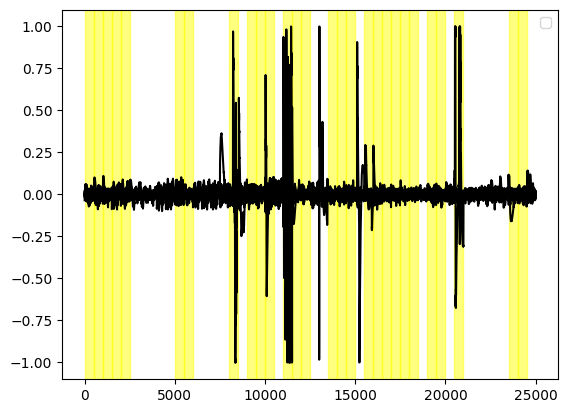

In [17]:
x_test_plot = x_test[:50].reshape(19, 50 * 500)

plt.Figure((15,8))
# Highlight sections: specify the ranges you want to highlight
highlight_ranges = []  # (start, end) pairs
pred_highlight_ranges = []  # (start, end) pairs
for i in range(channels): # 19
  plt.plot(x_test_plot[i], '-k')
  # run only for one channel
  if i==0:
    for i, h in enumerate(range(0, 25000, 500)):
      if y_test_new[i] in (1,2):
        highlight_ranges.append((h, h+500))
      if y_pred[i] in (1,2):
        pred_highlight_ranges.append((h, h+500))

# for start, end in highlight_ranges:
#     plt.axvspan(start, end, color='red', alpha=0.3)
for start, end in pred_highlight_ranges:
    plt.axvspan(start, end, color='yellow', alpha=0.5)
# plt.plot(range(0,25000,500), y_test[:50]==0, '.g', label='Normal data')
# plt.plot(range(0,25000,500), y_test[:50]==1, '.r', label='Complex partial seizures')
# plt.plot(range(0,25000,500), y_test[:50]==2, '.y', label='Electrograpic Seizures')
# plt.plot(range(0,25000,500), y_test[:50]==3, '.k', label='Video detected seizures')
plt.legend()

### Data labels

0: for Normal data<br>
1: for Complex Partial Seizures<br>
2: for Electrographic Seizures<br>
3: for Video-detected Seizures with no visual change over EEG<br>